# Env setup

In [290]:
import numpy as np
import pandas as pd
import umap.umap_ as umap
import os
from openai import OpenAI
import json
import pickle
from dotenv import load_dotenv
from Bio import Entrez, SeqIO
import time

In [2]:
load_dotenv()

True

In [3]:
# set up openAI
client = OpenAI(
    # This is the default and can be omitted
    api_key=os.getenv('OPEN_API_KEY'),
)

# generate embedding def
def get_gpt_embedding(text, model="text-embedding-ada-002"):
    text = text.replace("\n", " ")
    response = client.embeddings.create(input = [text], model=model)
    return np.array(response.data[0].embedding)

# define NCBI retrieval function


# test
print(get_gpt_embedding('hello'))

[-0.02512293 -0.01948714 -0.0280202  ... -0.01644434 -0.00505369
 -0.00600291]


In [4]:
'''
NCBI_summary_of_genes.json (NCBI gene card summary of human genes)
NCBI_UniProt_summary_of_genes.json (NCBI gene card and UniProt protein (when applicable) summary of human genes)
GenePT_gene_embedding_ada_text.pickle (a dictionary of numpy array where gene names (upper case) are keys and text-embedding-ada-002 embeddings of the summary in 1. are the values)
GenePT_gene_protein_embedding_model_3_text.pickle (a dictionary of numpy array where gene names (upper case) are keys and text-embedding-3-large embeddings of the summary in 1. are the values)
'''

# load datafiles
data_dir = r"../data/db_author"

# load NCBI json
with open(f"{data_dir}/NCBI_summary_of_genes.json", 'r') as file:
    NCBI_summary_of_genes = json.load(file)

with open(f"{data_dir}/NCBI_UniProt_summary_of_genes.json",'r') as file:
    NCBI_UniProt_summary = json.load(file)

#load pickle values
genept1_path = f"{data_dir}/GenePT_gene_embedding_ada_text.pickle"
genept2_path = f"{data_dir}/GenePT_gene_protein_embedding_model_3_text.pickle"

with open(genept1_path, 'rb') as file:
    GenePT_gene_embedding_ada = pickle.load(file)

with open(genept2_path,'rb') as file:
    GenePT_gene_protein_embedding = pickle.load(file)


In [5]:
#test print
print(NCBI_summary_of_genes['CD24'])

Gene Symbol CD24 This gene encodes a sialoglycoprotein that is expressed on mature granulocytes and B cells and modulates growth and differentiation signals to these cells. The precursor protein is cleaved to a short 32 amino acid mature peptide which is anchored via a glycosyl phosphatidylinositol (GPI) link to the cell surface. This gene was missing from previous genome assemblies, but is properly located on chromosome 6. Non-transcribed pseudogenes have been designated on chromosomes 1, 15, 20, and Y. Alternative splicing results in multiple transcript variants.


# Exploration with BRCA1

In [33]:

#generate embeddings
# sourced from: https://www.dana-farber.org/cancer-care/treatment/brca-related-genes/about#:~:text=Multiple%20other%20genes%20(referred%20to,NBN%2C%20MRE11A%2C%20and%20others.

'''
BRCA1 and BRCA2 occupy a central role in the repair of a specific type of damage to the DNA through a DNA repair pathway called homologous recombination repair (HRR). Multiple other genes (referred to as BRCA-related genes) also participate directly or indirectly in HRR. These genes include PALB2, BARD1, BRIP1, RAD50, RAD51C, RAD51D, RAD54L, ATM, ATR, ATRX, FANCONI anemia genes (e.g. FANCA, FANCB, FANCC), CHEK1, CHEK2, BLM, NBN, MRE11A, and others.
'''

import random
BRCA = "BRCA1"
BRCA_similar = ['PALB2', 'BARD1', 'BRIP1', 'RAD50', 'RAD51C', 'RAD51D', 'RAD54L', 'ATM', 'ATR', 'ATRX', 'FANCA', 'FANCB', 'FANCC', 'CHEK1', 'CHEK2', 'BLM', 'NBN']
negative_control = random.sample(list(NCBI_summary_of_genes.keys()), len(BRCA_similar))


In [7]:
for gene in BRCA_similar:
    print(f"BRCA Similar Gene {gene} : ", NCBI_summary_of_genes[gene])

for gene in negative_control:
    print(f"Control Gene {gene} : ", NCBI_summary_of_genes[gene])

BRCA Similar Gene PALB2 :  Gene Symbol PALB2 This gene encodes a protein that may function in tumor suppression. This protein binds to and colocalizes with the breast cancer 2 early onset protein (BRCA2) in nuclear foci and likely permits the stable intranuclear localization and accumulation of BRCA2.
BRCA Similar Gene BARD1 :  Gene Symbol BARD1 This gene encodes a protein which interacts with the N-terminal region of BRCA1. In addition to its ability to bind BRCA1 in vivo and in vitro, it shares homology with the 2 most conserved regions of BRCA1: the N-terminal RING motif and the C-terminal BRCT domain. The RING motif is a cysteine-rich sequence found in a variety of proteins that regulate cell growth, including the products of tumor suppressor genes and dominant protooncogenes. This protein also contains 3 tandem ankyrin repeats. The BARD1/BRCA1 interaction is disrupted by tumorigenic amino acid substitutions in BRCA1, implying that the formation of a stable complex between these pr

In [8]:
# embeddings
gene_name_embeddings = {}
gene_description_embedding = {}

# get reference
BRCA1_name_embedding = get_gpt_embedding('BRCA1')
BRCA1_description_embedding = get_gpt_embedding(NCBI_summary_of_genes['BRCA1'])

#compute embeddings for BRCA similar genes
for gene in BRCA_similar:
    gene_name_embeddings[gene] = get_gpt_embedding(gene)
    gene_description_embedding[gene] = get_gpt_embedding(NCBI_summary_of_genes[gene])

for gene in negative_control:
    gene_name_embeddings[gene] = get_gpt_embedding(gene)
    gene_description_embedding[gene] = get_gpt_embedding(NCBI_summary_of_genes[gene])

In [9]:
NCBI_summary_of_genes['BRCA1']

'Gene Symbol BRCA1 This gene encodes a 190 kD nuclear phosphoprotein that plays a role in maintaining genomic stability, and it also acts as a tumor suppressor. The BRCA1 gene contains 22 exons spanning about 110 kb of DNA. The encoded protein combines with other tumor suppressors, DNA damage sensors, and signal transducers to form a large multi-subunit protein complex known as the BRCA1-associated genome surveillance complex (BASC). This gene product associates with RNA polymerase II, and through the C-terminal domain, also interacts with histone deacetylase complexes. This protein thus plays a role in transcription, DNA repair of double-stranded breaks, and recombination. Mutations in this gene are responsible for approximately 40% of inherited breast cancers and more than 80% of inherited breast and ovarian cancers. Alternative splicing plays a role in modulating the subcellular localization and physiological function of this gene. Many alternatively spliced transcript variants, som

In [10]:
#values
plot_embeddings = np.array(list(gene_name_embeddings.values()))
plot_embeddings = np.append(
    plot_embeddings,
    np.array(list(gene_description_embedding.values())),
    axis = 0
)

#format labels
labels = list(gene_name_embeddings.keys())
colors = [key in BRCA_similar for key in labels]
for label in gene_name_embeddings.keys():
    labels.append(f"{label}_wDesc")
    if label in BRCA_similar:
        colors.append(True)
    else:
        colors.append(False)

# add BRCA1
plot_embeddings = np.append(plot_embeddings, [BRCA1_name_embedding], axis = 0)
labels.append("BRCA1")
colors.append(True)

# add BRCA1 w description
plot_embeddings = np.append(plot_embeddings, [BRCA1_description_embedding], axis = 0)
labels.append("BRCA1_wDesc")
colors.append(True)


#check
print(plot_embeddings.shape)
print(len(labels))
print(len(colors))

(70, 1536)
70
70


/Users/Jethro/Documents/GitHub/GenePT/genept/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


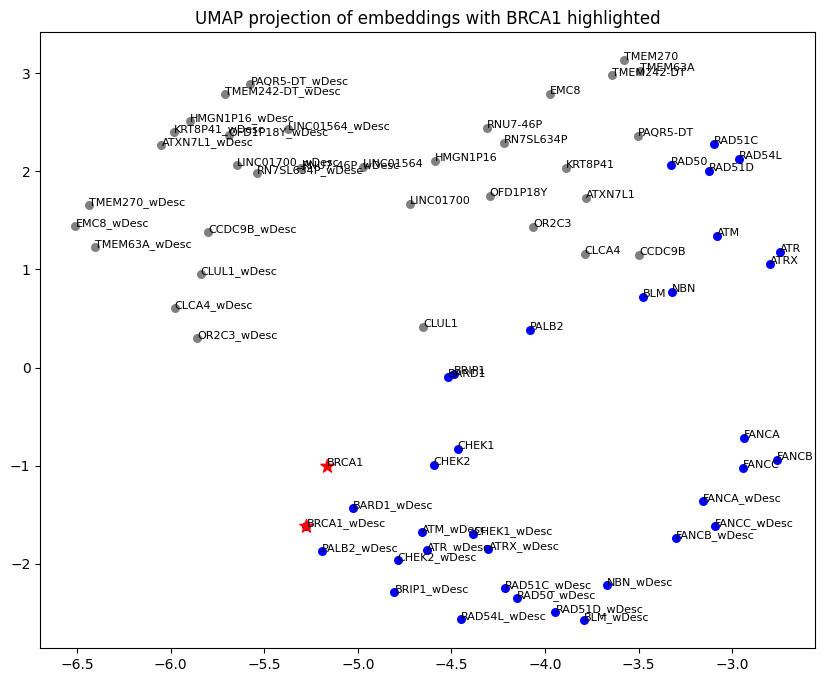

In [11]:
# explore dataset
import matplotlib.pyplot as plt


# UMAP projection to 2D
reducer = umap.UMAP(n_components=2, random_state=42)
embedding_2d = reducer.fit_transform(
    plot_embeddings
)  # shape (n_samples, 2)

# Plot the result
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

# Scatter plot for all points except BRCA1
for idx, (x, y) in enumerate(embedding_2d):
    if labels[idx] == "BRCA1":
        continue
    plt.scatter(
        x, y,
        c='blue' if colors[idx] else 'gray',
        s=30,
        marker='o'
    )

# Find BRCA1 index and plot as red star
if "BRCA1" in labels:
    brca1_idx = labels.index("BRCA1")
    plt.scatter(
        embedding_2d[brca1_idx, 0],
        embedding_2d[brca1_idx, 1],
        c='red',
        s=100,
        marker='*',
        label='BRCA1'
    )

if "BRCA1_wDesc" in labels:
    brca1_idx = labels.index("BRCA1_wDesc")
    plt.scatter(
        embedding_2d[brca1_idx, 0],
        embedding_2d[brca1_idx, 1],
        c='red',
        s=100,
        marker='*',
        label='BRCA1_wDesc'
    )

# Annotate all points
for i, txt in enumerate(labels):
    plt.annotate(txt, (embedding_2d[i, 0], embedding_2d[i, 1]), fontsize=8)

plt.title("UMAP projection of embeddings with BRCA1 highlighted")
plt.show()

In [12]:
# computing the embedding space differences
diff_embeddings = []
for embeddings in plot_embeddings:
    diff = BRCA1_description_embedding - embeddings
    diff_embeddings.append(diff)

diff_embeddings = np.array(diff_embeddings)
0
#check
print(diff_embeddings.shape)
print(len(labels))
print(len(colors))

(70, 1536)
70
70


/Users/Jethro/Documents/GitHub/GenePT/genept/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/Jethro/Documents/GitHub/GenePT/genept/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


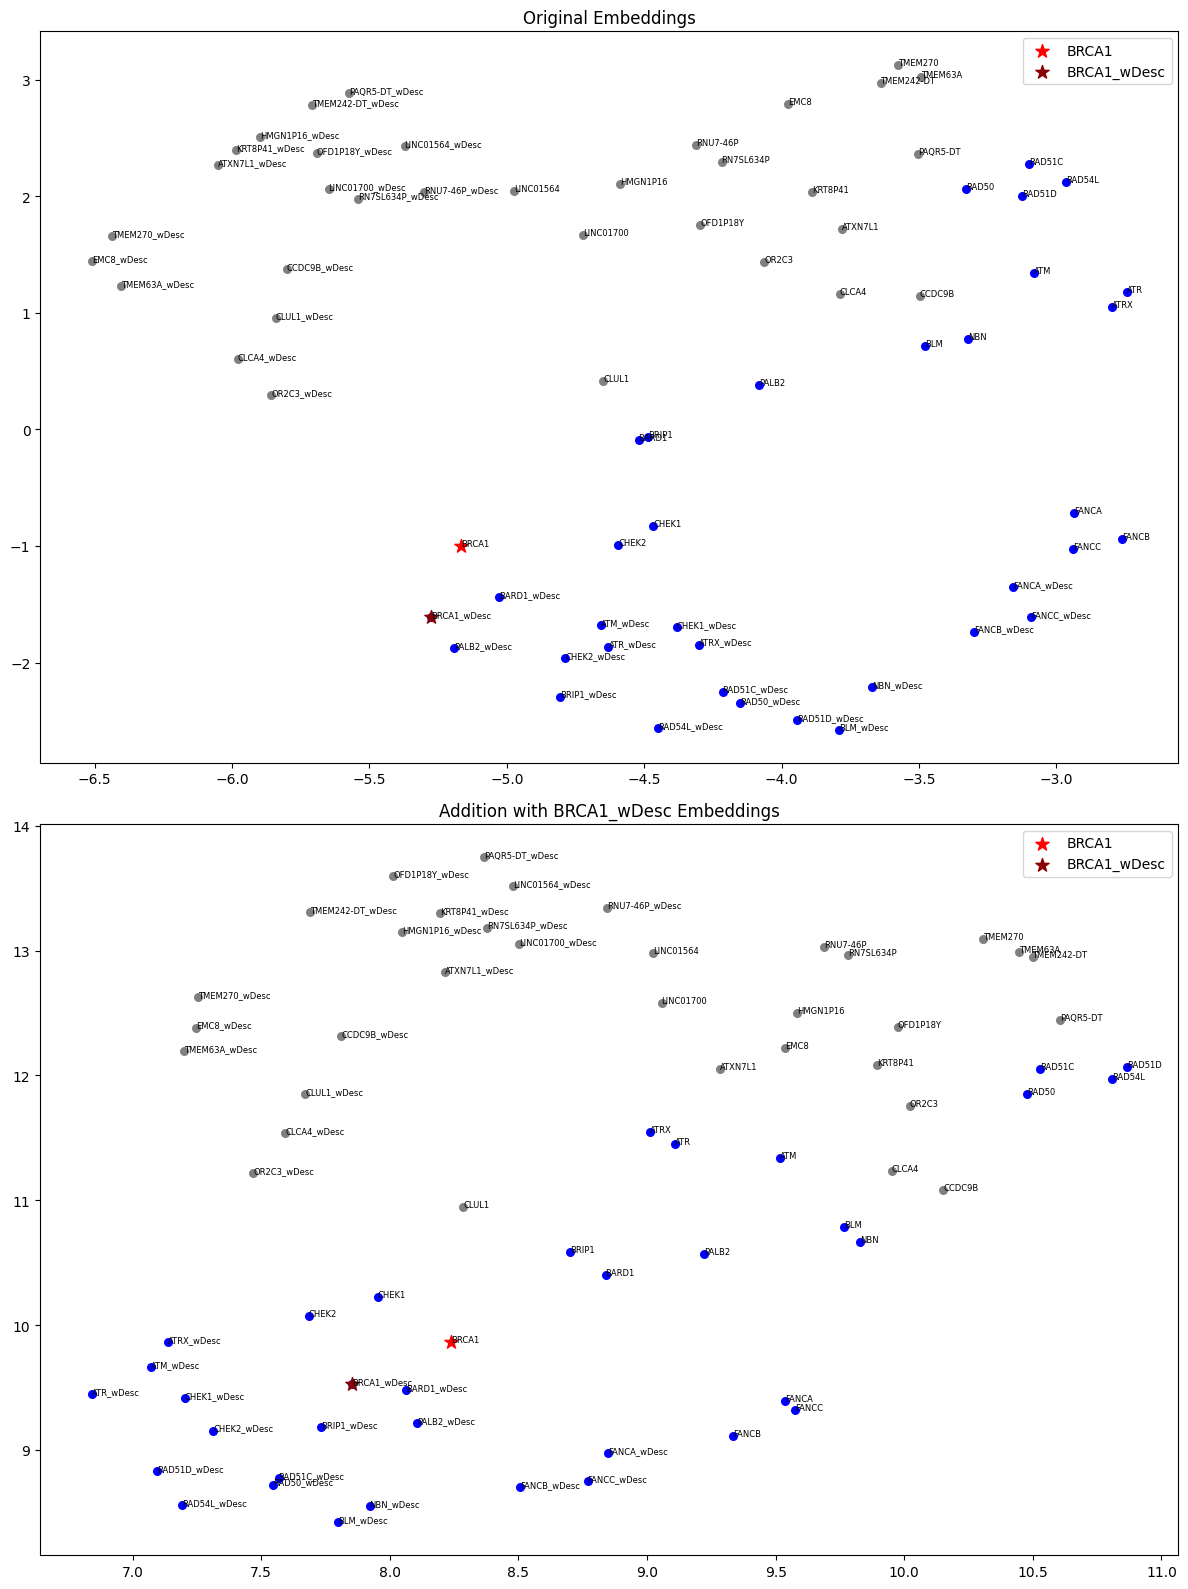

In [13]:
# Show both plots vertically for comparison
import matplotlib.pyplot as plt

# Create subplot with 2 rows, 1 column
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 16))

# First plot - Original embeddings
reducer1 = umap.UMAP(n_components=2, random_state=42)
embedding_2d_original = reducer1.fit_transform(plot_embeddings)

# Plot original embeddings
for idx, (x, y) in enumerate(embedding_2d_original):
    if labels[idx] == "BRCA1":
        continue
    ax1.scatter(
        x, y,
        c='blue' if colors[idx] else 'gray',
        s=30,
        marker='o'
    )

# Find and plot BRCA1 points for original
if "BRCA1" in labels:
    brca1_idx = labels.index("BRCA1")
    ax1.scatter(
        embedding_2d_original[brca1_idx, 0],
        embedding_2d_original[brca1_idx, 1],
        c='red', s=100, marker='*', label='BRCA1'
    )

if "BRCA1_wDesc" in labels:
    brca1_desc_idx = labels.index("BRCA1_wDesc")
    ax1.scatter(
        embedding_2d_original[brca1_desc_idx, 0],
        embedding_2d_original[brca1_desc_idx, 1],
        c='darkred', s=100, marker='*', label='BRCA1_wDesc'
    )

# Annotate original plot
for i, txt in enumerate(labels):
    ax1.annotate(txt, (embedding_2d_original[i, 0], embedding_2d_original[i, 1]), fontsize=6)

ax1.set_title("Original Embeddings")
ax1.legend()

# Second plot - Difference embeddings
reducer2 = umap.UMAP(n_components=2, random_state=42)
embedding_2d_diff = reducer2.fit_transform(diff_embeddings)

# Plot difference embeddings
for idx, (x, y) in enumerate(embedding_2d_diff):
    if labels[idx] == "BRCA1":
        continue
    ax2.scatter(
        x, y,
        c='blue' if colors[idx] else 'gray',
        s=30,
        marker='o'
    )

# Find and plot BRCA1 points for differences
if "BRCA1" in labels:
    brca1_idx = labels.index("BRCA1")
    ax2.scatter(
        embedding_2d_diff[brca1_idx, 0],
        embedding_2d_diff[brca1_idx, 1],
        c='red', s=100, marker='*', label='BRCA1'
    )

if "BRCA1_wDesc" in labels:
    brca1_desc_idx = labels.index("BRCA1_wDesc")
    ax2.scatter(
        embedding_2d_diff[brca1_desc_idx, 0],
        embedding_2d_diff[brca1_desc_idx, 1],
        c='darkred', s=100, marker='*', label='BRCA1_wDesc'
    )

# Annotate difference plot
for i, txt in enumerate(labels):
    ax2.annotate(txt, (embedding_2d_diff[i, 0], embedding_2d_diff[i, 1]), fontsize=6)

ax2.set_title("Addition with BRCA1_wDesc Embeddings")
ax2.legend()

plt.tight_layout()
plt.show()

In [14]:
#copmarison plot betweeen the positive & negative BRCA1

# Gene name 
# Gene + description 
# Gene + DNA sequence
# DNA sequence


# L2 distance metric

In [15]:
# top 5 to BRCA1
mean_diff = np.mean(diff_embeddings, axis = 1)
sorted_indices = np.argsort(mean_diff)
sorted_labels = np.array(labels)[sorted_indices]

In [16]:
sorted_labels[-5:]

array(['NBN', 'ATR', 'ATM', 'BARD1', 'RAD50'], dtype='<U16')

# Embedding with small test dataset

In [186]:
gene_analysis_path = r'../data/gene_analysis.json'
dna_path = r'../data/gene_dna.csv'
df = pd.read_json(gene_analysis_path)
dna_df = pd.read_csv(dna_path)

In [270]:
import random

# embeddings
target_gene_embedding = {}
target_description_embedding = {}
gene_name_embeddings = {}
gene_description_embedding = {}
control_name_embedding = {}
control_description_embedding = {}


def generate_embeddings(row):
    
    # get gene vals
    target_gene = row['target_gene']
    similar_genes = row['similar_genes_functional']
    
    # check if none
    if isinstance(similar_genes, float):
        return 

    # sample negative control
    if len(similar_genes) > 0:
        negative_control = random.sample(list(NCBI_summary_of_genes.keys()), len(similar_genes)) 
    
    # get reference
    target_gene_embedding[target_gene] = get_gpt_embedding(target_gene)
    target_description_embedding[target_gene] = get_gpt_embedding(NCBI_summary_of_genes[target_gene])

    #compute embeddings for similar genes\    
    for gene in similar_genes:
        try:
            if gene in NCBI_summary_of_genes:
                gene_name_embeddings[gene] = get_gpt_embedding(gene)
                gene_description_embedding[gene] = get_gpt_embedding(NCBI_summary_of_genes[gene])
        except Exception as e:
            print(f"Err in getting embedding for {gene}")
            continue

    #get neagtive control embeddings
    for gene in negative_control:
        control_name_embedding[gene] = get_gpt_embedding(gene)
        control_description_embedding[gene] = get_gpt_embedding(NCBI_summary_of_genes[gene])

In [271]:
# compute embeddings
for index, row in df.iterrows():
    generate_embeddings(row)

In [189]:
# Create gene-to-target mapping and get unique colors
gene_to_target = {}
target_genes = list(target_gene_embedding.keys())

# Map each gene to its target
for _, row in df.iterrows():
    target_gene = row['target_gene']
    similar_genes = row['similar_genes_functional']
    
    if isinstance(similar_genes,float):
        continue
    
    for gene in similar_genes:
        if gene in NCBI_summary_of_genes:
            gene_to_target[gene] = target_gene

In [278]:
target_gene_dict = {
    'target_gene' : target_gene_embedding.keys(),
    'target_name_GenePTembedding': target_gene_embedding.values(),
    'target_description_GenePTembedding': target_description_embedding.values(),
}

ref_gene_dict = {
    'reference_gene' : gene_name_embeddings.keys(),
    'reference_gene_GenePTembedding': gene_name_embeddings.values(),
    'reference_description_GenePTembedding': gene_description_embedding.values(),
}


control_gene_dict = {
    'control_gene' : control_name_embedding.keys(),
    'control_gene_GenePTembedding': control_name_embedding.values(),
    'control_description_GenePTembedding': control_description_embedding.values(),
}


In [279]:
# Convert dicts to DataFrames
df_target = pd.DataFrame(target_gene_dict)
df_ref = pd.DataFrame(ref_gene_dict)
df_control = pd.DataFrame(control_gene_dict)

# Save DataFrames as CSV only
df_target.to_csv("../data/df_target_gene.csv", index=False)
df_ref.to_csv("../data/df_ref_gene.csv", index=False)
df_control.to_csv("../data/df_control_gene.csv", index=False)

# Plots

In [276]:
# Create mapping of genes to their target genes
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

# Create color mapping for each target gene
colors = cm.tab10(np.linspace(0, 1, len(target_genes)))
target_color_map = dict(zip(target_genes, colors))

print(f"Target genes: {target_genes}")
print(f"Gene-to-target mapping: {len(gene_to_target)} genes mapped")

Target genes: ['TP53', 'BRCA1', 'CFTR', 'HBB', 'APOE', 'EGFR', 'MYC', 'AKT1', 'SRC', 'MAPK3']
Gene-to-target mapping: 46 genes mapped


In [283]:
name_embeddings = []
name_labels = []
name_colors = []
name_types = []

desc_embeddings = []
desc_labels = []
desc_colors = []
desc_types = []

# Target genes
for gene, embedding in zip(target_gene_dict['target_gene'], target_gene_dict['target_name_GenePTembedding']):
    name_embeddings.append(embedding)
    name_labels.append(gene)
    name_colors.append(target_color_map[gene])
    name_types.append('target')

for gene, embedding in zip(target_gene_dict['target_gene'], target_gene_dict['target_description_GenePTembedding']):
    desc_embeddings.append(embedding)
    desc_labels.append(gene)
    desc_colors.append(target_color_map[gene])
    desc_types.append('target')

# Reference genes
for gene, embedding in zip(ref_gene_dict['reference_gene'], ref_gene_dict['reference_gene_GenePTembedding']):
    name_embeddings.append(embedding)
    name_labels.append(gene)
    if gene in gene_to_target:
        name_colors.append(target_color_map[gene_to_target[gene]])
        name_types.append('similar')
    else:
        name_colors.append('cornflowerblue')
        name_types.append('reference')

for gene, embedding in zip(ref_gene_dict['reference_gene'], ref_gene_dict['reference_description_GenePTembedding']):
    desc_embeddings.append(embedding)
    desc_labels.append(gene)
    if gene in gene_to_target:
        desc_colors.append(target_color_map[gene_to_target[gene]])
        desc_types.append('similar')
    else:
        desc_colors.append('cornflowerblue')
        desc_types.append('reference')

# Control genes
for gene, embedding in zip(control_gene_dict['control_gene'], control_gene_dict['control_gene_GenePTembedding']):
    name_embeddings.append(embedding)
    name_labels.append(gene)
    name_colors.append('lightgray')
    name_types.append('control')

for gene, embedding in zip(control_gene_dict['control_gene'], control_gene_dict['control_description_GenePTembedding']):
    desc_embeddings.append(embedding)
    desc_labels.append(gene)
    desc_colors.append('lightgray')
    desc_types.append('control')

/Users/Jethro/Documents/GitHub/GenePT/genept/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/Jethro/Documents/GitHub/GenePT/genept/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


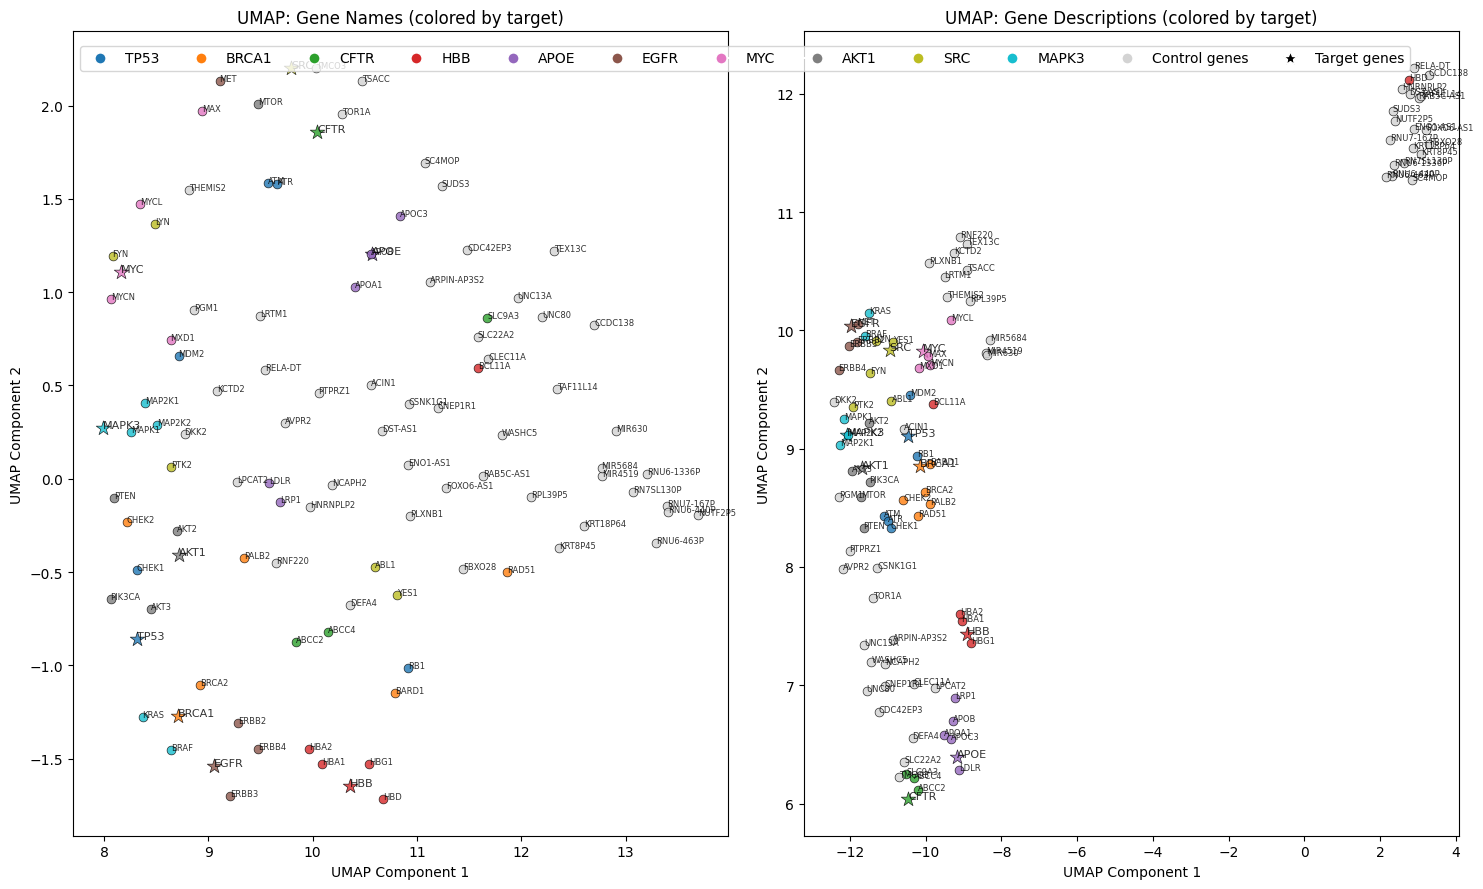

In [284]:
# Create side-by-side UMAP plots colored by target gene
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 9))

# Left plot - Gene names
reducer1 = umap.UMAP(n_components=2, random_state=42)
embedding_2d_names = reducer1.fit_transform(name_embeddings)

for idx, (x, y) in enumerate(embedding_2d_names):
    color = name_colors[idx]
    gene_type = name_types[idx]
    
    # Different markers for different types
    if gene_type == 'target':
        marker = '*'
        size = 120
    else:
        marker = 'o'
        size = 40
    
    ax1.scatter(x, y, c=[color], s=size, marker=marker, alpha=alpha, edgecolors='black', linewidths=0.5)

# Annotate gene names
for i, txt in enumerate(name_labels):
    ax1.annotate(txt, 
                (embedding_2d_names[i, 0], embedding_2d_names[i, 1]), 
                fontsize=8 if name_types[i] == 'target' else 6,
                alpha=0.8)

ax1.set_title("UMAP: Gene Names (colored by target)")
ax1.set_xlabel("UMAP Component 1")
ax1.set_ylabel("UMAP Component 2")

# Right plot - Gene descriptions
reducer2 = umap.UMAP(n_components=2, random_state=42)
embedding_2d_desc = reducer2.fit_transform(desc_embeddings)

for idx, (x, y) in enumerate(embedding_2d_desc):
    color = desc_colors[idx]
    gene_type = desc_types[idx]
    
    # Different markers for different types
    if gene_type == 'target':
        marker = '*'
        size = 120
    else:
        marker = 'o'
        size = 40
    
    ax2.scatter(x, y, c=[color], s=size, marker=marker, alpha=alpha, edgecolors='black', linewidths=0.5)

# Annotate descriptions
for i, txt in enumerate(desc_labels):
    ax2.annotate(txt, 
                (embedding_2d_desc[i, 0], embedding_2d_desc[i, 1]), 
                fontsize=8 if desc_types[i] == 'target' else 6,
                alpha=0.8)

ax2.set_title("UMAP: Gene Descriptions (colored by target)")
ax2.set_xlabel("UMAP Component 1")
ax2.set_ylabel("UMAP Component 2")

# Create shared legend
legend_elements = []
for target_gene, color in target_color_map.items():
    legend_elements.append(
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, 
                  markersize=8, label=target_gene)
    )
legend_elements.append(
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='lightgray', 
              markersize=8, label='Control genes')
)
legend_elements.append(
    plt.Line2D([0], [0], marker='*', color='w', markerfacecolor='black', 
              markersize=10, label='Target genes')
)

fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, 0.95), ncol=len(legend_elements))

plt.tight_layout()
plt.show()

# Drug interactions

In [285]:
import os
import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity
from matplotlib import pyplot as plt
import seaborn as sns

# Helper
import ast

# --- Prepare arrays for targets ---
target_names = list(target_gene_dict['target_gene'])
target_name_vecs = np.stack(list(target_gene_dict['target_name_GenePTembedding']))
target_desc_vecs = np.stack(list(target_gene_dict['target_description_GenePTembedding']))

# --- Prepare arrays for reference genes ---
ref_names = list(ref_gene_dict['reference_gene'])
ref_name_vecs = np.stack(list(ref_gene_dict['reference_gene_GenePTembedding']))
ref_desc_vecs = np.stack(list(ref_gene_dict['reference_description_GenePTembedding']))

# --- Prepare arrays for control genes ---
control_names = list(control_gene_dict['control_gene'])
control_name_vecs = np.stack(list(control_gene_dict['control_gene_GenePTembedding']))
control_desc_vecs = np.stack(list(control_gene_dict['control_description_GenePTembedding']))

In [286]:
import re

drug_names = {}
drug_embeddings = {}
drug_vectors = []

# Only keep rows with non-null drug info
drug_dfs = df[~df.drug_associated_interactions.isna()]

def extract_drug_name(s):
    if not isinstance(s, str):
        return None
    # Search for pattern like: {'drug_name': 'DRUG'}
    match = re.search(r"'drug_name':\s*'([^']+)'", s)
    return match.group(1) if match else None

for index, row in drug_dfs.iterrows():
    target_gene = row['target_gene']
    s = str(row['drug_associated_interactions'])
    drug = extract_drug_name(s)
    if drug:
        # Optionally censor out target gene from the drug name (if necessary)
        drug_clean = drug.replace(target_gene, '').strip()
        print(f"Target: {target_gene} - Drug: {drug_clean}")
        embedding = get_gpt_embedding(drug_clean)
        drug_embeddings[target_gene] = embedding
        drug_names[target_gene] = drug_clean
        drug_vectors.append(embedding)
    else:
        print(f"Target: {target_gene} - no drug found")

# Add negative drug control
neg_drug_control = "Dimethyl sulfoxide"
drug_control_vec = get_gpt_embedding(neg_drug_control)

Target: TP53 - no drug found
Target: BRCA1 - Drug: Olaparib (PARP inhibitor)
Target: CFTR - Drug: Ivacaftor ( potentiator)
Target: HBB - Drug: Hydroxyurea
Target: APOE - Drug: Atorvastatin
Target: EGFR - Drug: Gefitinib
Target: CYP2D6 - Drug: Codeine
Target: CYP2C19 - Drug: Clopidogrel
Target: VKORC1 - Drug: Warfarin
Target: EGFR - Drug: Gefitinib
Target: ERBB2 - Drug: Neratinib


In [287]:
# --- Interpolate gene+drug embeddings for targets ---
interp_gene_drug_targets = []
for i, gene in enumerate(target_names):
    if gene in drug_embeddings and drug_embeddings[gene] is not None:
        interp_vec = target_name_vecs[i] + drug_embeddings[gene]
    else:
        # Use control drug if none is found for the gene
        interp_vec = target_name_vecs[i] + drug_control_vec
    interp_gene_drug_targets.append(interp_vec)
interp_gene_drug_targets = np.stack(interp_gene_drug_targets)

# --- Interpolated controls (reference and control genes, all with the control drug vector) ---
interp_gene_drug_ref = ref_name_vecs + drug_control_vec           # (references)
interp_gene_desc_drug_ref = ref_desc_vecs + drug_control_vec       # (reference descriptions)
interp_gene_drug_controls = control_name_vecs + drug_control_vec   # (controls)
interp_gene_desc_drug_controls = control_desc_vecs + drug_control_vec

/var/folders/2d/0l2mg1j55w924ptz41_9t_2r0000gn/T/ipykernel_52287/49088272.py:63: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


<Figure size 1800x800 with 0 Axes>

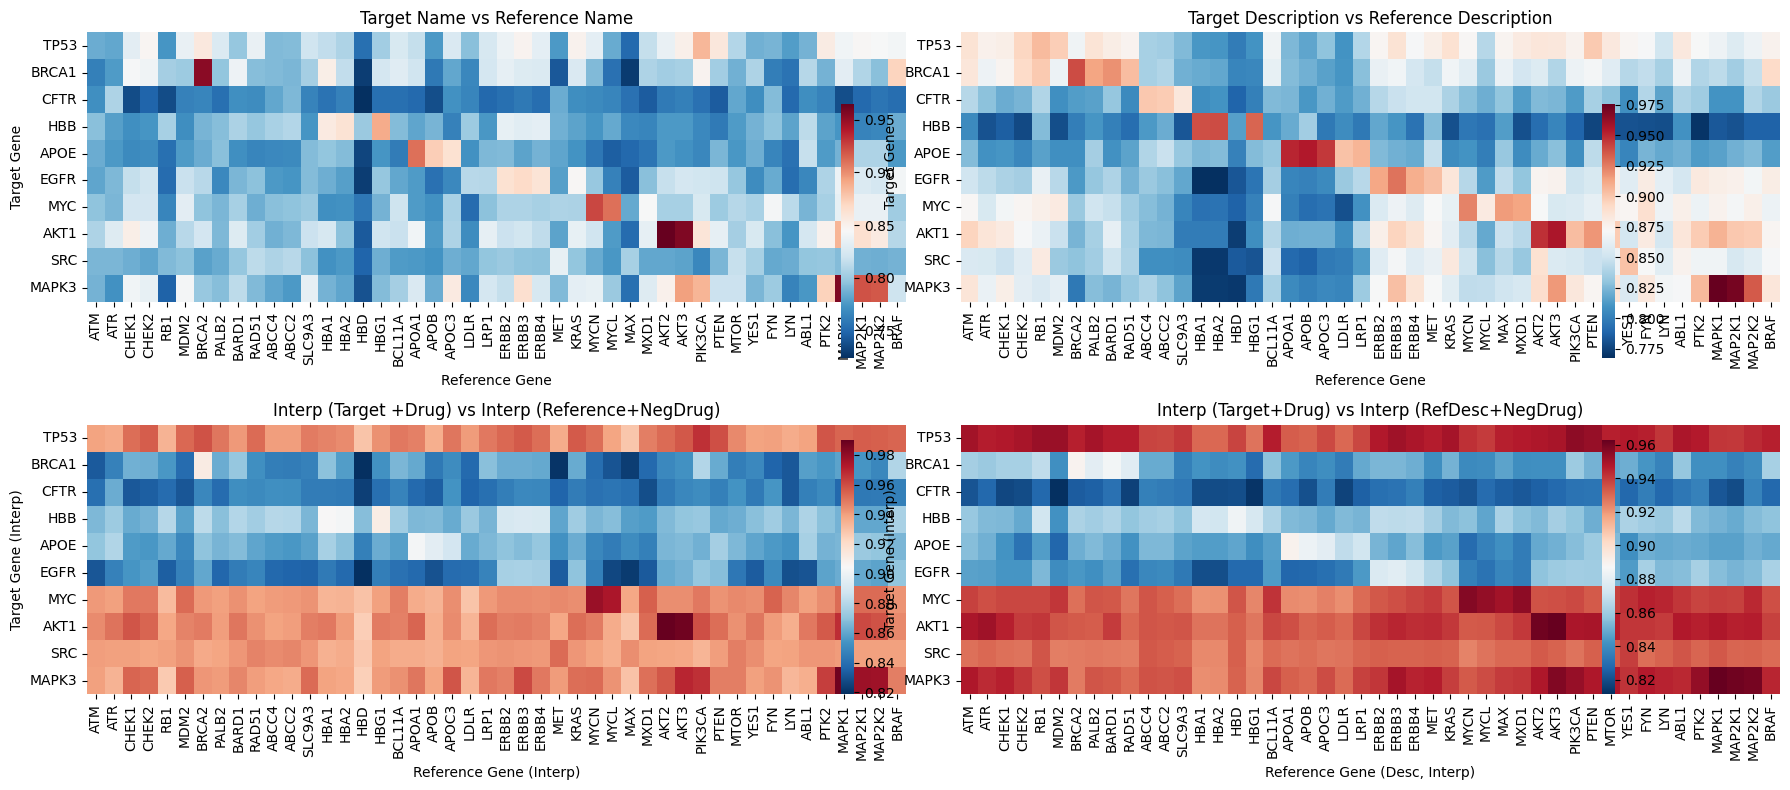

In [288]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity

plt.figure(figsize=(18, 8))
cbar_kws = dict(use_gridspec=False, location="right", fraction=0.02, pad=0.04)

plt.figure(figsize=(18, 8))
cbar_kws = dict(use_gridspec=False, location="right", fraction=0.02, pad=0.04)

# --- 1. Target gene name vs Reference gene name
plt.subplot(2, 2, 1)
sns.heatmap(
    cosine_similarity(target_name_vecs, ref_name_vecs), 
    cmap='RdBu_r', 
    cbar_kws=cbar_kws,
    xticklabels=ref_names,     
    yticklabels=target_names
)
plt.title('Target Name vs Reference Name')
plt.xlabel('Reference Gene')
plt.ylabel('Target Gene')

# --- 2. Target gene description vs Reference gene description
plt.subplot(2, 2, 2)
sns.heatmap(
    cosine_similarity(target_desc_vecs, ref_desc_vecs), 
    cmap='RdBu_r', 
    cbar_kws=cbar_kws,
    xticklabels=ref_names,
    yticklabels=target_names
)
plt.title('Target Description vs Reference Description')
plt.xlabel('Reference Gene')
plt.ylabel('Target Gene')

# --- 3. Interpolated (Target + Drug) vs interpolated Reference (gene+control drug)
plt.subplot(2, 2, 3)
sns.heatmap(
    cosine_similarity(interp_gene_drug_targets, interp_gene_drug_ref),
    cmap='RdBu_r',
    cbar_kws=cbar_kws,
    xticklabels=ref_names,
    yticklabels=target_names
)
plt.title('Interp (Target +Drug) vs Interp (Reference+NegDrug)')
plt.xlabel('Reference Gene (Interp)')
plt.ylabel('Target Gene (Interp)')

# --- 4. Interpolated (Target + Drug) vs Reference gene with control drug (description-based)
plt.subplot(2, 2, 4)
sns.heatmap(
    cosine_similarity(interp_gene_drug_targets, interp_gene_desc_drug_ref),
    cmap='RdBu_r',
    cbar_kws=cbar_kws,
    xticklabels=ref_names,
    yticklabels=target_names
)
plt.title('Interp (Target+Drug) vs Interp (RefDesc+NegDrug)')
plt.xlabel('Reference Gene (Desc, Interp)')
plt.ylabel('Target Gene (Interp)')

plt.tight_layout()
plt.show()

/Users/Jethro/Documents/GitHub/GenePT/genept/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


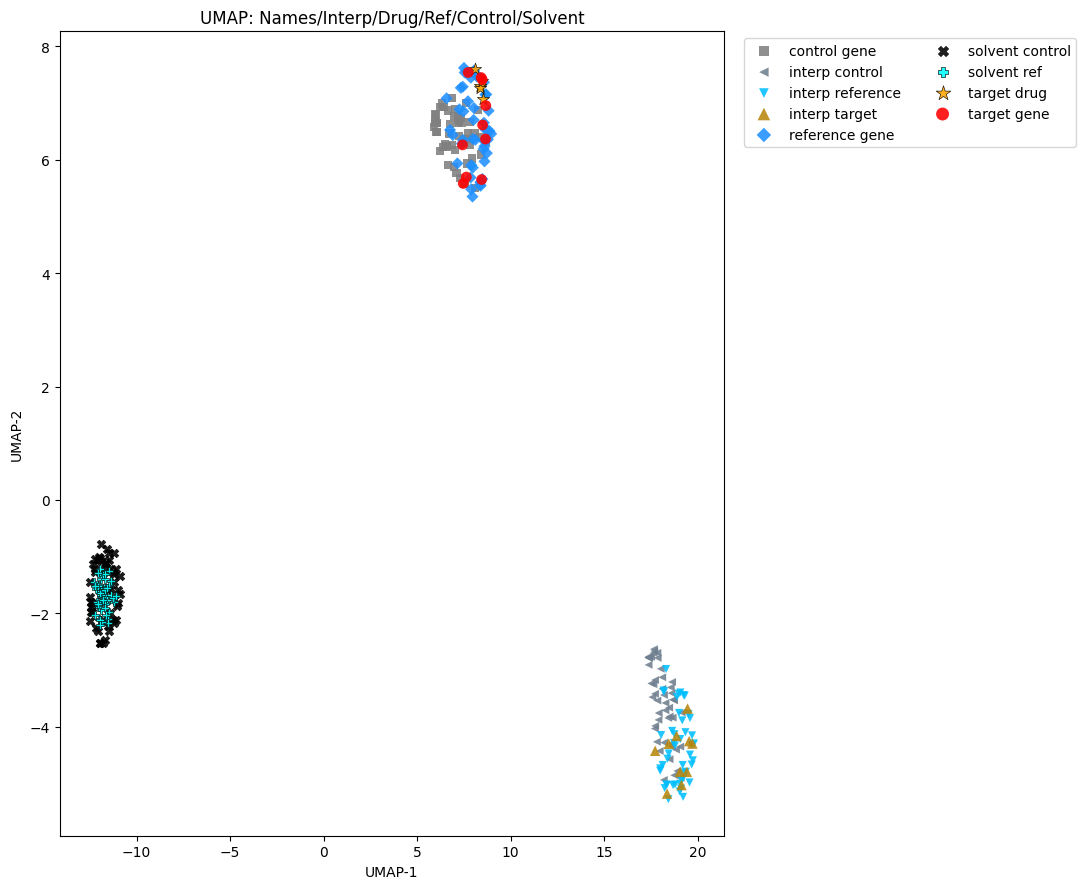

/Users/Jethro/Documents/GitHub/GenePT/genept/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


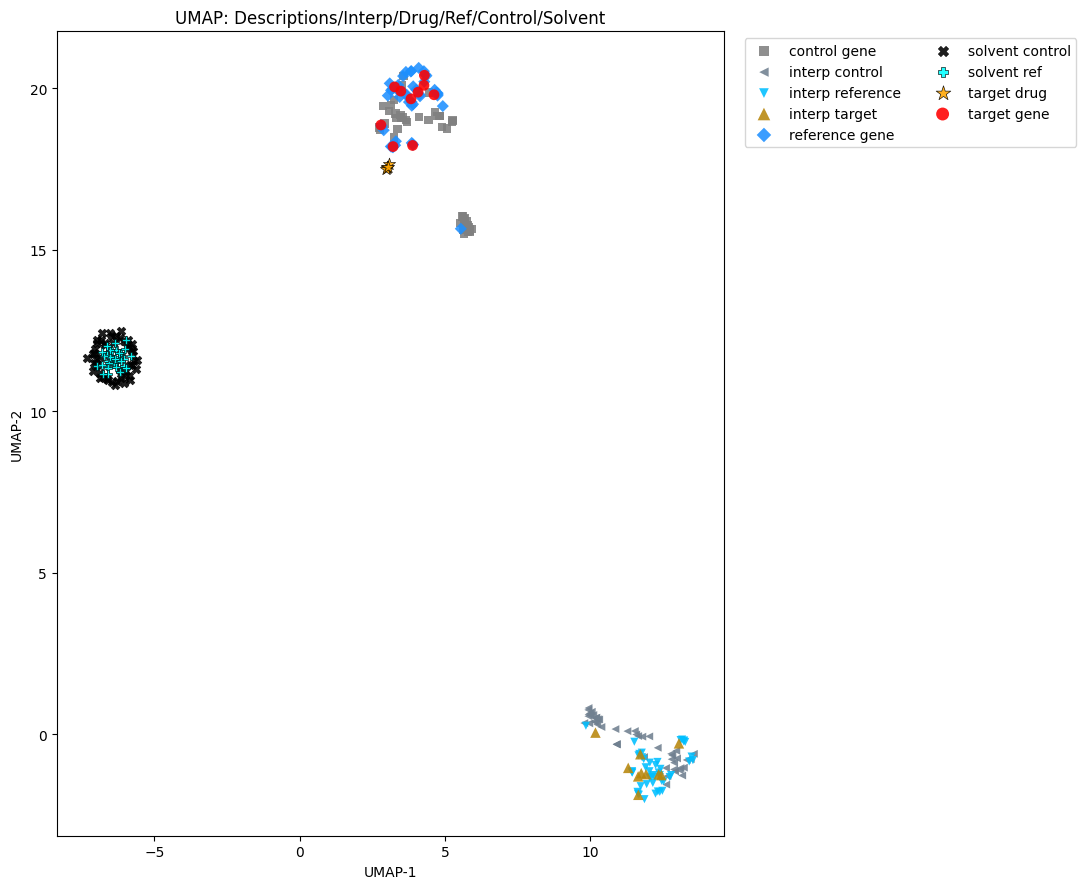

In [291]:
# Prepare matrix for control drugs ("solvent")
neg_drug_mat_ref = np.tile(drug_control_vec, (ref_name_vecs.shape[0], 1))
neg_drug_mat_ctrl = np.tile(drug_control_vec, (control_name_vecs.shape[0], 1))
drug_vectors = np.vstack([drug_embeddings[gene] for gene in target_names if gene in drug_embeddings])

# --- For gene name space ---
umap_gene_embs = np.vstack([
    target_name_vecs,                    # target_gene
    ref_name_vecs,                       # reference_gene
    control_name_vecs,                   # control_gene (true-neg)
    interp_gene_drug_targets,            # interp_target+drug
    interp_gene_drug_ref,                # interp_ref+solvent
    interp_gene_drug_controls,           # interp_control+solvent
    drug_vectors,                        # actual drugs (per target)
    neg_drug_mat_ref,                    # solvent controls (for refs)
    neg_drug_mat_ctrl,                   # solvent controls (for controls)
])

umap_gene_groups = (
    ['target_gene'] * target_name_vecs.shape[0] +
    ['reference_gene'] * ref_name_vecs.shape[0] +
    ['control_gene'] * control_name_vecs.shape[0] +
    ['interp_target'] * interp_gene_drug_targets.shape[0] +
    ['interp_reference'] * interp_gene_drug_ref.shape[0] +
    ['interp_control'] * interp_gene_drug_controls.shape[0] +
    ['target_drug'] * drug_vectors.shape[0] +
    ['solvent_ref'] * neg_drug_mat_ref.shape[0] +
    ['solvent_control'] * neg_drug_mat_ctrl.shape[0]
)

# --- For gene description space ---
umap_desc_embs = np.vstack([
    target_desc_vecs,
    ref_desc_vecs,
    control_desc_vecs,
    interp_gene_drug_targets,         # These remain name-based interpolations
    interp_gene_desc_drug_ref,        # interp_ref descriptions + solvent
    interp_gene_desc_drug_controls,   # interp_control descriptions + solvent
    drug_vectors,
    neg_drug_mat_ref,
    neg_drug_mat_ctrl,
])

umap_desc_groups = (
    ['target_gene'] * target_desc_vecs.shape[0] +
    ['reference_gene'] * ref_desc_vecs.shape[0] +
    ['control_gene'] * control_desc_vecs.shape[0] +
    ['interp_target'] * interp_gene_drug_targets.shape[0] +
    ['interp_reference'] * interp_gene_desc_drug_ref.shape[0] +
    ['interp_control'] * interp_gene_desc_drug_controls.shape[0] +
    ['target_drug'] * drug_vectors.shape[0] +
    ['solvent_ref'] * neg_drug_mat_ref.shape[0] +
    ['solvent_control'] * neg_drug_mat_ctrl.shape[0]
)

def plot_umap_combined(embeds, groups, title):
    
    reducer = umap.UMAP(n_components=2, random_state=42)
    emb2d = reducer.fit_transform(embeds)
    
    color_map = {
        'target_gene':      'red',
        'reference_gene':   'dodgerblue',
        'control_gene':     'gray',
        'interp_target':    'darkgoldenrod',
        'interp_reference': 'deepskyblue',
        'interp_control':   'slategray',
        'target_drug':      'orange',
        'solvent_ref':      'cyan',
        'solvent_control':  'black'
    }
    marker_map = {
        'target_gene':      'o',
        'reference_gene':   'D',
        'control_gene':     's',
        'interp_target':    '^',
        'interp_reference': 'v',
        'interp_control':   '<',
        'target_drug':      '*',
        'solvent_ref':      'P',
        'solvent_control':  'X'
    }
    sz = {
        'target_gene':      60,
        'reference_gene':   38,
        'control_gene':     35,
        'interp_target':    57,
        'interp_reference': 34,
        'interp_control':   32,
        'target_drug':      85,
        'solvent_ref':      33,
        'solvent_control':  38
    }
    plt.figure(figsize=(11,9))
    for group in np.unique(groups):
        idxs = [i for i, g in enumerate(groups) if g == group]
        plt.scatter(
            emb2d[idxs,0], emb2d[idxs,1],
            color=color_map[group],
            marker=marker_map[group],
            label=group.replace('_',' '),
            s=sz[group],
            alpha=0.88,
            edgecolors='k' if 'drug' in group or 'solvent' in group else 'none',
            linewidths=0.5
        )
    plt.title(title)
    plt.xlabel("UMAP-1")
    plt.ylabel("UMAP-2")
    plt.legend(ncol=2, markerscale=1.2, bbox_to_anchor=(1.02,1), loc='upper left')
    plt.tight_layout()
    plt.show()

# 4. --- Run UMAP plots ---
plot_umap_combined(umap_gene_embs, umap_gene_groups, "UMAP: Names/Interp/Drug/Ref/Control/Solvent")
plot_umap_combined(umap_desc_embs, umap_desc_groups, "UMAP: Descriptions/Interp/Drug/Ref/Control/Solvent")

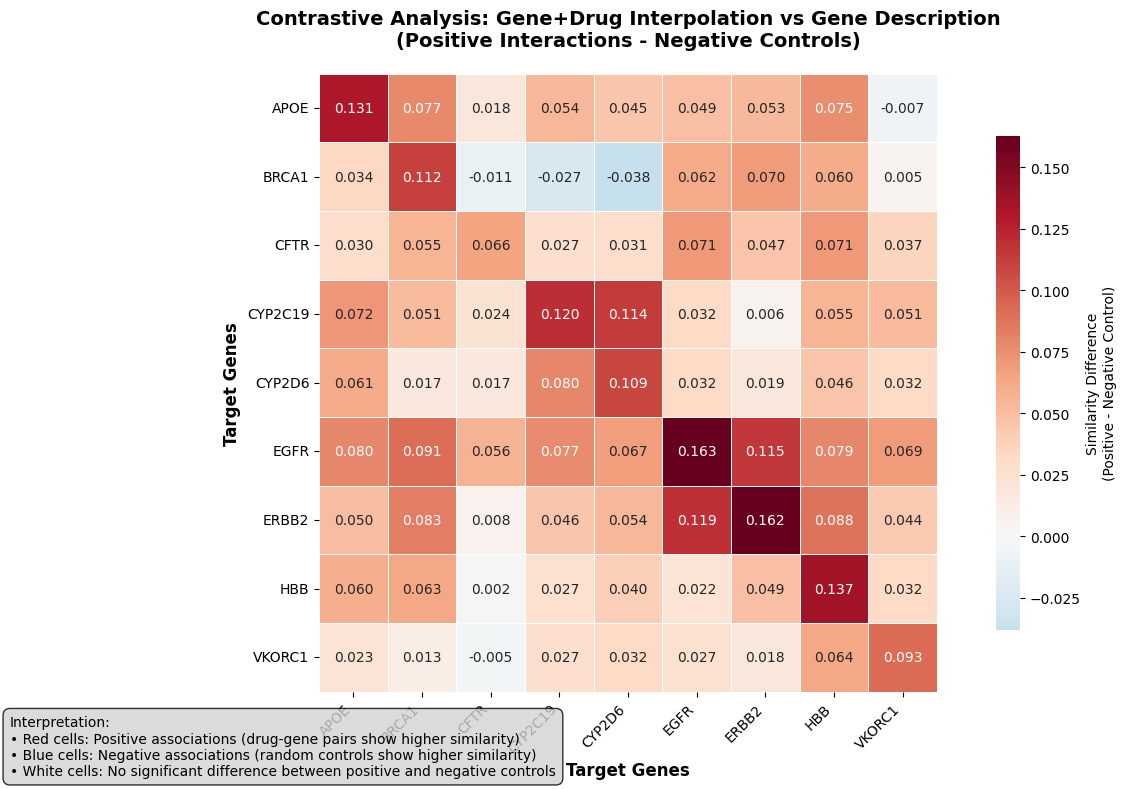

Contrastive Matrix Statistics:
Shape: (9, 9)
Mean difference: 0.0532
Std deviation: 0.0391
Min difference: -0.0381
Max difference: 0.1629
Positive values (drug > control): 76 / 81

Strongest positive association:
  EGFR vs EGFR: 0.1629

Strongest negative association:
  BRCA1 vs CYP2D6: -0.0381


In [ ]:
# contrastive map - Enhanced version with proper annotations
plt.figure(figsize=(12, 8))

# Calculate the contrastive difference matrix
contrastive_matrix = sim_interp_gene_desc_pos - sim_gene_name_desc_neg

# Create the heatmap with enhanced styling
ax = sns.heatmap(contrastive_matrix, 
                 cmap='RdBu_r',  # Red-Blue colormap (red=positive, blue=negative)
                 center=0,  # Center the colormap at 0
                 annot=True,  # Show values in cells
                 fmt='.3f',  # Format numbers to 3 decimal places
                 square=True,  # Make cells square
                 linewidths=0.5,  # Add gridlines
                 cbar_kws={'label': 'Similarity Difference\n(Positive - Negative Control)', 
                          'shrink': 0.8},
                 xticklabels=poslabels,  # Gene names on x-axis
                 yticklabels=poslabels)  # Gene names on y-axis (should match for square matrix)

# Customize the plot
plt.title('Contrastive Analysis: Gene+Drug Interpolation vs Gene Description\n' +
          '(Positive Interactions - Negative Controls)', 
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Target Genes', fontsize=12, fontweight='bold')
plt.ylabel('Target Genes', fontsize=12, fontweight='bold')

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

# Add interpretation text
plt.figtext(0.02, 0.02, 
           'Interpretation:\n' +
           '• Red cells: Positive associations (drug-gene pairs show higher similarity)\n' +
           '• Blue cells: Negative associations (random controls show higher similarity)\n' +
           '• White cells: No significant difference between positive and negative controls',
           fontsize=10, ha='left', va='bottom',
           bbox=dict(boxstyle="round,pad=0.5", facecolor='lightgray', alpha=0.8))

plt.tight_layout()
plt.show()

# Print summary statistics
print(f"Contrastive Matrix Statistics:")
print(f"Shape: {contrastive_matrix.shape}")
print(f"Mean difference: {np.mean(contrastive_matrix):.4f}")
print(f"Std deviation: {np.std(contrastive_matrix):.4f}")
print(f"Min difference: {np.min(contrastive_matrix):.4f}")
print(f"Max difference: {np.max(contrastive_matrix):.4f}")
print(f"Positive values (drug > control): {np.sum(contrastive_matrix > 0)} / {contrastive_matrix.size}")

# Identify strongest positive and negative associations
max_idx = np.unravel_index(np.argmax(contrastive_matrix), contrastive_matrix.shape)
min_idx = np.unravel_index(np.argmin(contrastive_matrix), contrastive_matrix.shape)

print(f"\nStrongest positive association:")
print(f"  {poslabels[max_idx[0]]} vs {poslabels[max_idx[1]]}: {contrastive_matrix[max_idx]:.4f}")
print(f"\nStrongest negative association:")
print(f"  {poslabels[min_idx[0]]} vs {poslabels[min_idx[1]]}: {contrastive_matrix[min_idx]:.4f}")